# EvoRank data evaluation (Phase 1 gate)

Interactive companion to `data/data_report.py`. Run this after `data/prepare_expedia.py`
and before any baselines or evolution runs. It validates the prepared dataset,
reports the numbers the paper's Experimental Setup section needs, and visualizes
the distributions that justify the three-objective design.

The script version (`python data/data_report.py`) is the authoritative gate with
exit codes; this notebook is for inspection and figure drafts.

Falls back to synthetic data if no prepared Expedia parquet exists, so it runs anywhere.

In [1]:
import pathlib, sys, time
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ltr.dataset import get_dataset
from ltr.metrics import grouped_ndcg, group_sizes_of

train_df, val_df, test_df, feats, src = get_dataset(fast=True)
folds = {"train": train_df, "val": val_df, "test": test_df}
print(f"source: {src}   features: {len(feats)}")
for name, f in folds.items():
    print(f"{name:5s} queries {f.qid.nunique():>8}  rows {len(f):>10}")

source: expedia:prepared_fast   features: 24
train queries      120  rows       1882
val   queries       24  rows        388
test  queries       24  rows        365


## 1. Split integrity and label consistency (hard checks)

These mirror the hard checks in `data_report.py`. Every assert here must pass
before spending tokens on the loop.

In [2]:
tr_q, va_q, te_q = (set(f["qid"]) for f in folds.values())
assert not (tr_q & va_q) and not (tr_q & te_q) and not (va_q & te_q), "query spans folds"

for name, f in folds.items():
    qid = f["qid"].to_numpy()
    assert int((qid[1:] != qid[:-1]).sum()) + 1 == f["qid"].nunique(), f"{name}: groups not contiguous"

all_df = pd.concat(folds.values())
assert set(np.unique(all_df["rel"])) <= {0, 1, 5}
assert set(np.unique(all_df["booking"])) <= {0, 1}
assert (all_df["rev"] >= 0).all()
assert (all_df.loc[all_df["booking"] == 0, "rev"] == 0).all()
assert ((all_df["rel"] == 5) == (all_df["booking"] == 1)).all()
print("all hard checks passed")

all hard checks passed


## 2. Label and group distributions

Numbers for the paper: label balance, group sizes, booking coverage per fold.
Sparse positives are expected (bookings are rare events); what matters is that
every fold has scoreable queries on all three metrics.

train rel {0: 1401, 1: 383, 5: 98}  group size med 16  queries w/ booking 74.2%
val   rel {0: 290, 1: 78, 5: 20}  group size med 17  queries w/ booking 79.2%
test  rel {0: 264, 1: 82, 5: 19}  group size med 14  queries w/ booking 66.7%


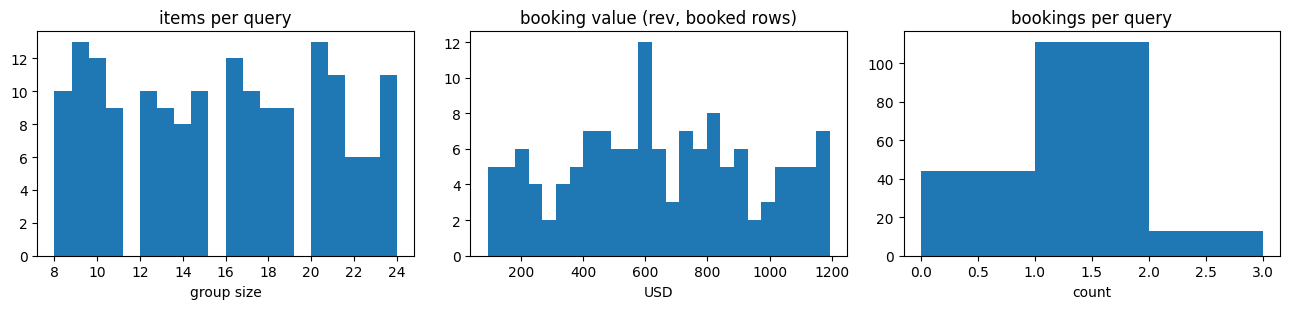

In [3]:
for name, f in folds.items():
    gs = f.groupby("qid", sort=False).size()
    booked_q = (f.groupby("qid")["booking"].sum() > 0)
    print(f"{name:5s} rel {f['rel'].value_counts().sort_index().to_dict()}  "
          f"group size med {int(gs.median())}  queries w/ booking {booked_q.mean():.1%}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
gs_all = all_df.groupby("qid", sort=False).size()
axes[0].hist(gs_all, bins=20); axes[0].set_title("items per query"); axes[0].set_xlabel("group size")
booked_rev = all_df.loc[all_df["booking"] == 1, "rev"]
axes[1].hist(booked_rev, bins=25); axes[1].set_title("booking value (rev, booked rows)"); axes[1].set_xlabel("USD")
per_q_book = all_df.groupby("qid")["booking"].sum()
axes[2].hist(per_q_book, bins=range(0, int(per_q_book.max()) + 2)); axes[2].set_title("bookings per query"); axes[2].set_xlabel("count")
plt.tight_layout(); plt.show()

## 3. Pareto divergence: do the three objectives genuinely compete?

The multi-objective story requires that book_ndcg and revenue can disagree,
which happens only in queries with more than one booking at different values.
This cell quantifies that share. If it is near zero, the two metrics coincide
and the paper must say so; on the real Expedia data it is nonzero.

In [4]:
def divergence(f):
    multi = diverge = with_book = 0
    for _, g in f.groupby("qid", sort=False):
        b = g["booking"].to_numpy(); r = g["rev"].to_numpy()
        nb = int(b.sum())
        if nb == 0: continue
        with_book += 1
        if nb > 1:
            multi += 1
            if len(np.unique(r[b == 1])) > 1:
                diverge += 1
    return (multi / with_book, diverge / with_book) if with_book else (0.0, 0.0)

for name, f in folds.items():
    m, d = divergence(f)
    flag = "" if m > 0 else "  <- WARN: book_ndcg and revenue will coincide"
    print(f"{name:5s} >1 booking {m:.1%}   ordering divergence {d:.1%}{flag}")

if "random_flag" in all_df.columns:
    print(f"random subset: {all_df['random_flag'].mean():.1%} of rows "
          f"(position-unbiased impressions, debiasing asset)")

train >1 booking 10.1%   ordering divergence 10.1%
val   >1 booking 5.3%   ordering divergence 5.3%
test  >1 booking 18.8%   ordering divergence 18.8%
random subset: 29.9% of rows (position-unbiased impressions, debiasing asset)


## 4. Metric behavior on this data

Sanity anchors before any training: a random scorer sets the floor, and an
oracle scorer (score = gain) sets the ceiling at 1.0. Any trained model must
land between them. The gap between random and oracle is the available headroom.

In [5]:
rng = np.random.default_rng(0)
for name, f in [("val", val_df)]:
    gs = group_sizes_of(f)
    gains = {
        "ndcg":      (2.0 ** f["rel"].to_numpy() - 1.0),
        "book_ndcg": f["booking"].to_numpy().astype(float),
        "revenue":   f["rev"].to_numpy().astype(float),
    }
    rand = rng.normal(size=len(f))
    print(f"{name} fold:")
    for metric, gain in gains.items():
        floor = grouped_ndcg(gain, rand, gs, 10)
        ceil  = grouped_ndcg(gain, gain, gs, 10)
        print(f"  {metric:10s} random {floor:.4f}   oracle {ceil:.4f}   headroom {ceil - floor:.4f}")

val fold:
  ndcg       random 0.3387   oracle 1.0000   headroom 0.6613
  book_ndcg  random 0.3097   oracle 1.0000   headroom 0.6903
  revenue    random 0.3096   oracle 1.0000   headroom 0.6904


## 5. Per-candidate evaluation cost

The evolution loop trains one ranker per candidate. This times a full
`evaluate()` call on the fast subset against the 60s budget. On the real data,
if this exceeds the budget, shrink `--fast-queries` in `prepare_expedia.py`
rather than cutting training rounds (rounds are part of the frozen config).

In [6]:
from eval.evaluator import evaluate
t0 = time.time()
res = evaluate(str(ROOT / "seed" / "initial_program.py"))
dt = time.time() - t0
print(f"wall time {dt:.1f}s (budget 60s)")
print("seed metrics:", res["artifacts"]["feedback"])
assert res["combined_score"] > 0, "seed program failed to score"
n_candidates = 40 * 2 * 3  # iterations x conditions x seeds
print(f"projected training compute for the full ablation: ~{dt * n_candidates / 60:.0f} min "
      f"({n_candidates} candidate evaluations), excluding LLM latency")

wall time 1.7s (budget 60s)
seed metrics: ndcg=0.3907 book=0.3584 rev=0.3587
projected training compute for the full ablation: ~7 min (240 candidate evaluations), excluding LLM latency


## 6. Gate decision

If every cell above ran clean: data is cleared. Proceed in order:
1. `python baselines/lambdamart_default.py` and the other three baselines (Phase 2).
2. The two evolutionary configs at 3 seeds each (Phase 3-4).
3. `python baselines/retune_best.py --program <best>` as the post-hoc control.

If the divergence check warned, or timing exceeded budget, fix the data or the
fast-subset size first. Do not start the loop on data that fails this notebook.